In [1]:
#Preparing Enviornment
#Load Necessary Libraries 
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import scipy.stats as stats
from scipy.stats import chi2_contingency
from IPython.display import clear_output
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import make_scorer, roc_auc_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, roc_auc_score

In [34]:
#Loading Train Data Files
#Loading Beneficiary Train Data
file_beneficiary_train = '/Users/keriwilkins/Downloads/Medicare-Fraud-Detection-DS/Train_Beneficiarydata-1542865627584.csv'

In [35]:
beneficiary_train_data = pd.read_csv(file_beneficiary_train)

In [36]:
print((beneficiary_train_data).shape)

(138556, 25)


In [37]:
print((beneficiary_train_data).dtypes)

BeneID                             object
DOB                                object
DOD                                object
Gender                              int64
Race                                int64
RenalDiseaseIndicator              object
State                               int64
County                              int64
NoOfMonths_PartACov                 int64
NoOfMonths_PartBCov                 int64
ChronicCond_Alzheimer               int64
ChronicCond_Heartfailure            int64
ChronicCond_KidneyDisease           int64
ChronicCond_Cancer                  int64
ChronicCond_ObstrPulmonary          int64
ChronicCond_Depression              int64
ChronicCond_Diabetes                int64
ChronicCond_IschemicHeart           int64
ChronicCond_Osteoporasis            int64
ChronicCond_rheumatoidarthritis     int64
ChronicCond_stroke                  int64
IPAnnualReimbursementAmt            int64
IPAnnualDeductibleAmt               int64
OPAnnualReimbursementAmt          

In [38]:
print(beneficiary_train_data)

            BeneID         DOB  DOD  Gender  Race RenalDiseaseIndicator  \
0        BENE11001  1943-01-01  NaN       1     1                     0   
1        BENE11002  1936-09-01  NaN       2     1                     0   
2        BENE11003  1936-08-01  NaN       1     1                     0   
3        BENE11004  1922-07-01  NaN       1     1                     0   
4        BENE11005  1935-09-01  NaN       1     1                     0   
...            ...         ...  ...     ...   ...                   ...   
138551  BENE159194  1939-07-01  NaN       1     1                     0   
138552  BENE159195  1938-12-01  NaN       2     1                     0   
138553  BENE159196  1916-06-01  NaN       2     1                     0   
138554  BENE159197  1930-01-01  NaN       1     1                     0   
138555  BENE159198  1952-04-01  NaN       2     1                     0   

        State  County  NoOfMonths_PartACov  NoOfMonths_PartBCov  ...  \
0          39     230      

In [39]:
missing_beneficiary_train = beneficiary_train_data.isnull().sum()

print(missing_beneficiary_train)

BeneID                                  0
DOB                                     0
DOD                                137135
Gender                                  0
Race                                    0
RenalDiseaseIndicator                   0
State                                   0
County                                  0
NoOfMonths_PartACov                     0
NoOfMonths_PartBCov                     0
ChronicCond_Alzheimer                   0
ChronicCond_Heartfailure                0
ChronicCond_KidneyDisease               0
ChronicCond_Cancer                      0
ChronicCond_ObstrPulmonary              0
ChronicCond_Depression                  0
ChronicCond_Diabetes                    0
ChronicCond_IschemicHeart               0
ChronicCond_Osteoporasis                0
ChronicCond_rheumatoidarthritis         0
ChronicCond_stroke                      0
IPAnnualReimbursementAmt                0
IPAnnualDeductibleAmt                   0
OPAnnualReimbursementAmt          

In [40]:
print(beneficiary_train_data.describe())

              Gender           Race          State         County  \
count  138556.000000  138556.000000  138556.000000  138556.000000   
mean        1.570932       1.254511      25.666734     374.424745   
std         0.494945       0.717007      15.223443     266.277581   
min         1.000000       1.000000       1.000000       0.000000   
25%         1.000000       1.000000      11.000000     141.000000   
50%         2.000000       1.000000      25.000000     340.000000   
75%         2.000000       1.000000      39.000000     570.000000   
max         2.000000       5.000000      54.000000     999.000000   

       NoOfMonths_PartACov  NoOfMonths_PartBCov  ChronicCond_Alzheimer  \
count        138556.000000        138556.000000          138556.000000   
mean             11.907727            11.910145               1.667817   
std               1.032332             0.936893               0.470998   
min               0.000000             0.000000               1.000000   
25%     

In [41]:
#Loading Inpatient Train Data
file_inpatient_train = '/Users/keriwilkins/Downloads/Medicare-Fraud-Detection-DS/Train_Inpatientdata-1542865627584.csv'

In [42]:
inpatient_train_data = pd.read_csv(file_inpatient_train)

In [43]:
print((inpatient_train_data).shape)

(40474, 30)


In [44]:
print((inpatient_train_data).dtypes)

BeneID                     object
ClaimID                    object
ClaimStartDt               object
ClaimEndDt                 object
Provider                   object
InscClaimAmtReimbursed      int64
AttendingPhysician         object
OperatingPhysician         object
OtherPhysician             object
AdmissionDt                object
ClmAdmitDiagnosisCode      object
DeductibleAmtPaid         float64
DischargeDt                object
DiagnosisGroupCode         object
ClmDiagnosisCode_1         object
ClmDiagnosisCode_2         object
ClmDiagnosisCode_3         object
ClmDiagnosisCode_4         object
ClmDiagnosisCode_5         object
ClmDiagnosisCode_6         object
ClmDiagnosisCode_7         object
ClmDiagnosisCode_8         object
ClmDiagnosisCode_9         object
ClmDiagnosisCode_10        object
ClmProcedureCode_1        float64
ClmProcedureCode_2        float64
ClmProcedureCode_3        float64
ClmProcedureCode_4        float64
ClmProcedureCode_5        float64
ClmProcedureCo

In [45]:
print(inpatient_train_data)

           BeneID   ClaimID ClaimStartDt  ClaimEndDt  Provider  \
0       BENE11001  CLM46614   2009-04-12  2009-04-18  PRV55912   
1       BENE11001  CLM66048   2009-08-31  2009-09-02  PRV55907   
2       BENE11001  CLM68358   2009-09-17  2009-09-20  PRV56046   
3       BENE11011  CLM38412   2009-02-14  2009-02-22  PRV52405   
4       BENE11014  CLM63689   2009-08-13  2009-08-30  PRV56614   
...           ...       ...          ...         ...       ...   
40469  BENE159167  CLM69886   2009-09-28  2009-10-02  PRV53671   
40470  BENE159175  CLM74504   2009-11-03  2009-11-06  PRV54981   
40471  BENE159177  CLM76485   2009-11-18  2009-11-22  PRV56588   
40472  BENE159177  CLM79949   2009-12-17  2009-12-18  PRV56575   
40473  BENE159188  CLM69948   2009-09-28  2009-10-06  PRV54765   

       InscClaimAmtReimbursed AttendingPhysician OperatingPhysician  \
0                       26000          PHY390922                NaN   
1                        5000          PHY318495          PHY3184

In [46]:
missing_inpatient_train = inpatient_train_data.isnull().sum()

print(missing_inpatient_train)

BeneID                        0
ClaimID                       0
ClaimStartDt                  0
ClaimEndDt                    0
Provider                      0
InscClaimAmtReimbursed        0
AttendingPhysician          112
OperatingPhysician        16644
OtherPhysician            35784
AdmissionDt                   0
ClmAdmitDiagnosisCode         0
DeductibleAmtPaid           899
DischargeDt                   0
DiagnosisGroupCode            0
ClmDiagnosisCode_1            0
ClmDiagnosisCode_2          226
ClmDiagnosisCode_3          676
ClmDiagnosisCode_4         1534
ClmDiagnosisCode_5         2894
ClmDiagnosisCode_6         4838
ClmDiagnosisCode_7         7258
ClmDiagnosisCode_8         9942
ClmDiagnosisCode_9        13497
ClmDiagnosisCode_10       36547
ClmProcedureCode_1        17326
ClmProcedureCode_2        35020
ClmProcedureCode_3        39509
ClmProcedureCode_4        40358
ClmProcedureCode_5        40465
ClmProcedureCode_6        40474
dtype: int64


In [47]:
print(inpatient_train_data.describe())

       InscClaimAmtReimbursed  DeductibleAmtPaid  ClmProcedureCode_1  \
count            40474.000000            39575.0        23148.000000   
mean             10087.884074             1068.0         5894.611759   
std              10303.099402                0.0         3049.304400   
min                  0.000000             1068.0           11.000000   
25%               4000.000000             1068.0         3848.000000   
50%               7000.000000             1068.0         5369.000000   
75%              12000.000000             1068.0         8666.250000   
max             125000.000000             1068.0         9999.000000   

       ClmProcedureCode_2  ClmProcedureCode_3  ClmProcedureCode_4  \
count         5454.000000          965.000000          116.000000   
mean          4103.738174         4226.355440         4070.172414   
std           2028.182156         2282.761581         1994.409802   
min             42.000000           42.000000           42.000000   
25%   

In [48]:
#Loading Outpatient Train Data
file_outpatient_train = '/Users/keriwilkins/Downloads/Medicare-Fraud-Detection-DS/Train_Outpatientdata-1542865627584.csv'

In [49]:
outpatient_train_data = pd.read_csv(file_outpatient_train)

In [50]:
print((outpatient_train_data).shape)

(517737, 27)


In [51]:
print((outpatient_train_data).dtypes)

BeneID                     object
ClaimID                    object
ClaimStartDt               object
ClaimEndDt                 object
Provider                   object
InscClaimAmtReimbursed      int64
AttendingPhysician         object
OperatingPhysician         object
OtherPhysician             object
ClmDiagnosisCode_1         object
ClmDiagnosisCode_2         object
ClmDiagnosisCode_3         object
ClmDiagnosisCode_4         object
ClmDiagnosisCode_5         object
ClmDiagnosisCode_6         object
ClmDiagnosisCode_7         object
ClmDiagnosisCode_8         object
ClmDiagnosisCode_9         object
ClmDiagnosisCode_10        object
ClmProcedureCode_1        float64
ClmProcedureCode_2        float64
ClmProcedureCode_3        float64
ClmProcedureCode_4        float64
ClmProcedureCode_5        float64
ClmProcedureCode_6        float64
DeductibleAmtPaid           int64
ClmAdmitDiagnosisCode      object
dtype: object


In [52]:
print(outpatient_train_data)

            BeneID    ClaimID ClaimStartDt  ClaimEndDt  Provider  \
0        BENE11002  CLM624349   2009-10-11  2009-10-11  PRV56011   
1        BENE11003  CLM189947   2009-02-12  2009-02-12  PRV57610   
2        BENE11003  CLM438021   2009-06-27  2009-06-27  PRV57595   
3        BENE11004  CLM121801   2009-01-06  2009-01-06  PRV56011   
4        BENE11004  CLM150998   2009-01-22  2009-01-22  PRV56011   
...            ...        ...          ...         ...       ...   
517732  BENE159198  CLM510792   2009-08-06  2009-08-06  PRV53699   
517733  BENE159198  CLM551294   2009-08-29  2009-08-29  PRV53702   
517734  BENE159198  CLM596444   2009-09-24  2009-09-24  PRV53676   
517735  BENE159198  CLM636992   2009-10-18  2009-10-18  PRV53689   
517736  BENE159198  CLM686139   2009-11-17  2009-11-18  PRV53689   

        InscClaimAmtReimbursed AttendingPhysician OperatingPhysician  \
0                           30          PHY326117                NaN   
1                           80         

In [53]:
missing_outpatient_train = outpatient_train_data.isnull().sum()

print(missing_outpatient_train)

BeneID                         0
ClaimID                        0
ClaimStartDt                   0
ClaimEndDt                     0
Provider                       0
InscClaimAmtReimbursed         0
AttendingPhysician          1396
OperatingPhysician        427120
OtherPhysician            322691
ClmDiagnosisCode_1         10453
ClmDiagnosisCode_2        195380
ClmDiagnosisCode_3        314480
ClmDiagnosisCode_4        392141
ClmDiagnosisCode_5        443393
ClmDiagnosisCode_6        468981
ClmDiagnosisCode_7        484776
ClmDiagnosisCode_8        494825
ClmDiagnosisCode_9        502899
ClmDiagnosisCode_10       516654
ClmProcedureCode_1        517575
ClmProcedureCode_2        517701
ClmProcedureCode_3        517733
ClmProcedureCode_4        517735
ClmProcedureCode_5        517737
ClmProcedureCode_6        517737
DeductibleAmtPaid              0
ClmAdmitDiagnosisCode     412312
dtype: int64


In [54]:
print(outpatient_train_data.describe())

       InscClaimAmtReimbursed  ClmProcedureCode_1  ClmProcedureCode_2  \
count           517737.000000          162.000000           36.000000   
mean               286.334799         6116.611111         4503.277778   
std                694.034343         3217.719258         2504.015000   
min                  0.000000           51.000000          412.000000   
25%                 40.000000         3893.000000         2724.000000   
50%                 80.000000         5244.500000         4019.000000   
75%                200.000000         9421.500000         5849.000000   
max             102500.000000         9999.000000         9982.000000   

       ClmProcedureCode_3  ClmProcedureCode_4  ClmProcedureCode_5  \
count            4.000000            2.000000                 0.0   
mean          2959.000000         4075.500000                 NaN   
std           1863.455393         5323.806956                 NaN   
min            412.000000          311.000000                 NaN 

In [55]:
#Loading Provider Fraud File Train Data
file_train = '/Users/keriwilkins/Downloads/Medicare-Fraud-Detection-DS/Train-1542865627584.csv'

In [56]:
train_data = pd.read_csv(file_train)

In [57]:
print((train_data).shape)

(5410, 2)


In [58]:
print((train_data).dtypes)

Provider          object
PotentialFraud    object
dtype: object


In [59]:
print(train_data)

      Provider PotentialFraud
0     PRV51001             No
1     PRV51003            Yes
2     PRV51004             No
3     PRV51005            Yes
4     PRV51007             No
...        ...            ...
5405  PRV57759             No
5406  PRV57760             No
5407  PRV57761             No
5408  PRV57762             No
5409  PRV57763             No

[5410 rows x 2 columns]


In [60]:
missing_train = train_data.isnull().sum()

print(missing_train)

Provider          0
PotentialFraud    0
dtype: int64


In [61]:
#Potential Fraud Distribution
fraud_counts = train_data['PotentialFraud'].value_counts()

print(fraud_counts)

PotentialFraud
No     4904
Yes     506
Name: count, dtype: int64


In [62]:
#Merging Beneficiary Train Data, Inpatient Train Data and Outpatient Train Data
# Step 1: Merge the DataFrames
combined_data = pd.merge(beneficiary_train_data, inpatient_train_data, on='BeneID', how='outer', suffixes=('_beneficiary', '_inpatient'))
combined_data = pd.merge(combined_data, outpatient_train_data, on='BeneID', how='outer', suffixes=('', '_outpatient'))

# Step 2: Identify columns to combine
columns_to_combine = []
for col in combined_data.columns:
    if col.endswith('_beneficiary') or col.endswith('_inpatient') or col.endswith('_outpatient'):
        base_col_name = col.split('_')[0]  # Get the base column name before any suffix
        if base_col_name in columns_to_combine:
            continue
        if (base_col_name + '_beneficiary' in combined_data.columns) and (base_col_name + '_inpatient' in combined_data.columns):
            columns_to_combine.append(base_col_name)
        elif (base_col_name + '_outpatient' in combined_data.columns):
            columns_to_combine.append(base_col_name)

# Step 3: Combine columns
for col in columns_to_combine:
    col_beneficiary = f"{col}_beneficiary" if f"{col}_beneficiary" in combined_data.columns else None
    col_inpatient = f"{col}_inpatient" if f"{col}_inpatient" in combined_data.columns else None
    col_outpatient = f"{col}_outpatient" if f"{col}_outpatient" in combined_data.columns else None
    
    # Combine Columns
    combined_data[col] = None
    if col_beneficiary:
        combined_data[col] = combined_data[col].combine_first(combined_data[col_beneficiary])
    if col_inpatient:
        combined_data[col] = combined_data[col].combine_first(combined_data[col_inpatient])
    if col_outpatient:
        combined_data[col] = combined_data[col].combine_first(combined_data[col_outpatient])
    
    # Drop Columns
    if col_beneficiary:
        combined_data.drop(columns=[col_beneficiary], inplace=True)
    if col_inpatient:
        combined_data.drop(columns=[col_inpatient], inplace=True)
    if col_outpatient:
        combined_data.drop(columns=[col_outpatient], inplace=True)

# Step 4: Remove Duplicates 
combined_data.drop_duplicates(inplace=True)

print(combined_data)

            BeneID         DOB  DOD  Gender  Race RenalDiseaseIndicator  \
0        BENE11001  1943-01-01  NaN       1     1                     0   
1        BENE11001  1943-01-01  NaN       1     1                     0   
2        BENE11001  1943-01-01  NaN       1     1                     0   
3        BENE11002  1936-09-01  NaN       2     1                     0   
4        BENE11003  1936-08-01  NaN       1     1                     0   
...            ...         ...  ...     ...   ...                   ...   
570906  BENE159198  1952-04-01  NaN       2     1                     0   
570907  BENE159198  1952-04-01  NaN       2     1                     0   
570908  BENE159198  1952-04-01  NaN       2     1                     0   
570909  BENE159198  1952-04-01  NaN       2     1                     0   
570910  BENE159198  1952-04-01  NaN       2     1                     0   

        State  County  NoOfMonths_PartACov  NoOfMonths_PartBCov  ...  \
0          39     230      

In [63]:
print("Beneficiary Columns:", beneficiary_train_data.columns)
print("Inpatient Columns:", inpatient_train_data.columns)
print("Outpatient Columns:", outpatient_train_data.columns)
print("Combined Columns:", combined_data.columns)

Beneficiary Columns: Index(['BeneID', 'DOB', 'DOD', 'Gender', 'Race', 'RenalDiseaseIndicator',
       'State', 'County', 'NoOfMonths_PartACov', 'NoOfMonths_PartBCov',
       'ChronicCond_Alzheimer', 'ChronicCond_Heartfailure',
       'ChronicCond_KidneyDisease', 'ChronicCond_Cancer',
       'ChronicCond_ObstrPulmonary', 'ChronicCond_Depression',
       'ChronicCond_Diabetes', 'ChronicCond_IschemicHeart',
       'ChronicCond_Osteoporasis', 'ChronicCond_rheumatoidarthritis',
       'ChronicCond_stroke', 'IPAnnualReimbursementAmt',
       'IPAnnualDeductibleAmt', 'OPAnnualReimbursementAmt',
       'OPAnnualDeductibleAmt'],
      dtype='object')
Inpatient Columns: Index(['BeneID', 'ClaimID', 'ClaimStartDt', 'ClaimEndDt', 'Provider',
       'InscClaimAmtReimbursed', 'AttendingPhysician', 'OperatingPhysician',
       'OtherPhysician', 'AdmissionDt', 'ClmAdmitDiagnosisCode',
       'DeductibleAmtPaid', 'DischargeDt', 'DiagnosisGroupCode',
       'ClmDiagnosisCode_1', 'ClmDiagnosisCode_2', 'Cl

In [64]:
print(combined_data[['ClmDiagnosisCode_1', 'ClmDiagnosisCode_1_outpatient']].head())

  ClmDiagnosisCode_1 ClmDiagnosisCode_1_outpatient
0               1970                           NaN
1               6186                           NaN
2              29623                           NaN
3                NaN                         78943
4                NaN                          6115


In [65]:
#Merging Combined Data With Provider Fraud Train Data
merged_data = pd.merge(combined_data, train_data, on='Provider', how='left', suffixes=('', '_train'))

print("Merged DataFrame:")
print(merged_data.head())

Merged DataFrame:
      BeneID         DOB  DOD  Gender  Race RenalDiseaseIndicator  State  \
0  BENE11001  1943-01-01  NaN       1     1                     0     39   
1  BENE11001  1943-01-01  NaN       1     1                     0     39   
2  BENE11001  1943-01-01  NaN       1     1                     0     39   
3  BENE11002  1936-09-01  NaN       2     1                     0     39   
4  BENE11003  1936-08-01  NaN       1     1                     0     52   

   County  NoOfMonths_PartACov  NoOfMonths_PartBCov  ...  \
0     230                   12                   12  ...   
1     230                   12                   12  ...   
2     230                   12                   12  ...   
3     280                   12                   12  ...   
4     590                   12                   12  ...   

   ClmDiagnosisCode_8_outpatient  ClmDiagnosisCode_9_outpatient  \
0                            NaN                            NaN   
1                            N

In [66]:
print("Merged DataFrame Columns:")
print(merged_data.columns)

Merged DataFrame Columns:
Index(['BeneID', 'DOB', 'DOD', 'Gender', 'Race', 'RenalDiseaseIndicator',
       'State', 'County', 'NoOfMonths_PartACov', 'NoOfMonths_PartBCov',
       'ChronicCond_Alzheimer', 'ChronicCond_Heartfailure',
       'ChronicCond_KidneyDisease', 'ChronicCond_Cancer',
       'ChronicCond_ObstrPulmonary', 'ChronicCond_Depression',
       'ChronicCond_Diabetes', 'ChronicCond_IschemicHeart',
       'ChronicCond_Osteoporasis', 'ChronicCond_rheumatoidarthritis',
       'ChronicCond_stroke', 'IPAnnualReimbursementAmt',
       'IPAnnualDeductibleAmt', 'OPAnnualReimbursementAmt',
       'OPAnnualDeductibleAmt', 'ClaimID', 'ClaimStartDt', 'ClaimEndDt',
       'Provider', 'InscClaimAmtReimbursed', 'AttendingPhysician',
       'OperatingPhysician', 'OtherPhysician', 'AdmissionDt',
       'ClmAdmitDiagnosisCode', 'DeductibleAmtPaid', 'DischargeDt',
       'DiagnosisGroupCode', 'ClmDiagnosisCode_1', 'ClmDiagnosisCode_2',
       'ClmDiagnosisCode_3', 'ClmDiagnosisCode_4', 'ClmDi

In [67]:
print(merged_data.isnull().sum())

BeneID                                0
DOB                                   0
DOD                              566734
Gender                                0
Race                                  0
                                  ...  
ClmProcedureCode_3_outpatient    570844
ClmProcedureCode_4_outpatient    570846
ClmProcedureCode_5_outpatient    570848
ClmProcedureCode_6_outpatient    570848
PotentialFraud                     5426
Length: 71, dtype: int64


In [68]:
print(merged_data.describe())

              Gender           Race          State         County  \
count  570848.000000  570848.000000  570848.000000  570848.000000   
mean        1.579419       1.256010      25.429661     379.067433   
std         0.493653       0.717028      15.190727     265.205826   
min         1.000000       1.000000       1.000000       0.000000   
25%         1.000000       1.000000      11.000000     150.000000   
50%         2.000000       1.000000      24.000000     350.000000   
75%         2.000000       1.000000      38.000000     570.000000   
max         2.000000       5.000000      54.000000     999.000000   

       NoOfMonths_PartACov  NoOfMonths_PartBCov  ChronicCond_Alzheimer  \
count        570848.000000        570848.000000          570848.000000   
mean             11.930920            11.940378               1.583725   
std               0.892791             0.774836               0.492941   
min               0.000000             0.000000               1.000000   
25%     

In [69]:
#Data Cleaning
#Coercing Object Datetime Columns To DateTime Format
DateTime_Cols = ['DOB','DOD','ClaimStartDt','ClaimEndDt','AdmissionDt','DischargeDt']

for col in DateTime_Cols:
    merged_data[col] = pd.to_datetime(merged_data[col], format='%Y-%m-%d', errors='coerce')

In [70]:
#Feature Engineering
#Creating Age Column From DOB
def calculate_age(DOB):
    # Calculate the current date
    current_date = pd.Timestamp.now()
    
    # Calculate the age
    if pd.isna(DOB):
        return np.nan  # Return NaN if DOB is missing
    else:
        age_difference = current_date - DOB
        return age_difference.days / 365.25  # Convert days to years accounting for leap years

# Apply the function to the DOB column
merged_data['Age'] = merged_data['DOB'].apply(calculate_age)

# Display the first few rows to check the result
print(merged_data[['DOB', 'Age']].head())


         DOB        Age
0 1943-01-01  81.930185
1 1943-01-01  81.930185
2 1943-01-01  81.930185
3 1936-09-01  88.262834
4 1936-08-01  88.347707


In [71]:
#Creating Deceased From Column Date of Death
merged_data['Deceased'] = merged_data['DOD'].notna().astype(int)

In [72]:
print(merged_data.loc[0:10, 'Deceased'])

0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
Name: Deceased, dtype: int64


In [73]:
#Extracting Claim Processing Time Using Claim Start Date and Claim End Date
merged_data['ClaimProcessingTime'] = (merged_data['ClaimEndDt'] - merged_data['ClaimStartDt']).dt.days

In [74]:
print(merged_data.loc[0:20, 'ClaimProcessingTime'])

0      NaN
1      NaN
2      NaN
3      0.0
4      0.0
5      0.0
6      0.0
7      0.0
8      0.0
9      0.0
10     0.0
11    20.0
12    12.0
13     0.0
14     0.0
15     0.0
16     0.0
17     0.0
18     0.0
19     0.0
20     0.0
Name: ClaimProcessingTime, dtype: float64


In [75]:
#Creating Claim Start Month / Start Year 
merged_data['ClaimStartYear'] = merged_data['ClaimStartDt'].dt.year
merged_data['ClaimStartMonth'] = merged_data['ClaimStartDt'].dt.month

In [76]:
print(merged_data.loc[0:5, 'ClaimStartYear'])

0       NaN
1       NaN
2       NaN
3    2009.0
4    2009.0
5    2009.0
Name: ClaimStartYear, dtype: float64


In [77]:
print(merged_data.loc[0:5, 'ClaimStartMonth'])

0     NaN
1     NaN
2     NaN
3    10.0
4     2.0
5     6.0
Name: ClaimStartMonth, dtype: float64


In [78]:
#Admission Date and Discharge Date For Length of Stay
merged_data['LengthOfStay'] = (merged_data['DischargeDt'] - merged_data['AdmissionDt']).dt.days

In [79]:
print(merged_data.loc[0:5, 'LengthOfStay'])

0    6.0
1    2.0
2    3.0
3    NaN
4    NaN
5    NaN
Name: LengthOfStay, dtype: float64


In [80]:
#Admission Start Month and Day
merged_data['AdmissionYear'] = merged_data['AdmissionDt'].dt.year
merged_data['AdmissionMonth'] = merged_data['AdmissionDt'].dt.month

In [81]:
print(merged_data.loc[0:5, 'AdmissionYear'])

0    2009.0
1    2009.0
2    2009.0
3       NaN
4       NaN
5       NaN
Name: AdmissionYear, dtype: float64


In [82]:
print(merged_data.loc[0:5, 'AdmissionMonth'])

0    4.0
1    8.0
2    9.0
3    NaN
4    NaN
5    NaN
Name: AdmissionMonth, dtype: float64


In [83]:
#Data Pre - Processing / Cleaning
#Dropping Missing or NAN Values From Potential Fraud Target Variable
merged_data = merged_data.dropna(subset=['PotentialFraud'])


In [84]:
#Encoding Target Variable Potential Fraud
#Binary Categorical Column With 'Yes'/'No'
merged_data['PotentialFraud'] = merged_data['PotentialFraud'].map({'Yes': 1, 'No': 2})  # if it's 'Yes'/'No'


In [85]:
#Data Pre-Processing / Cleaning 
#Fill Missing Or Nan Values For Length of Stay, Admission Year, Admission Month 
Admission_Columns = ['LengthOfStay', 'AdmissionYear', 'AdmissionMonth']
merged_data[Admission_Columns] = merged_data[Admission_Columns].fillna(0)

In [86]:
#Feature Selection
#Point - Biserial Correlation (Numerical and Binary Target)
Numerical_Binary_Columns = ['Gender', 'ChronicCond_Alzheimer','ChronicCond_Heartfailure',
                            'ChronicCond_KidneyDisease','ChronicCond_Cancer','ChronicCond_ObstrPulmonary',
                            'ChronicCond_Depression','ChronicCond_Diabetes','ChronicCond_IschemicHeart','ChronicCond_Osteoporasis',
                            'ChronicCond_rheumatoidarthritis','ChronicCond_stroke','NoOfMonths_PartACov', 
                            'NoOfMonths_PartBCov','IPAnnualReimbursementAmt','IPAnnualDeductibleAmt','OPAnnualReimbursementAmt',
                            'OPAnnualDeductibleAmt','InscClaimAmtReimbursed','DeductibleAmtPaid','Age','ClaimProcessingTime',
                            'ClaimStartYear','LengthOfStay','AdmissionYear', 'ClaimStartMonth', 'AdmissionMonth', 'Deceased']

# Calculate the correlation matrix
point_biserial_corr = {}

for col in Numerical_Binary_Columns:
    corr, _ = stats.pointbiserialr(merged_data[col], merged_data['PotentialFraud'])
    point_biserial_corr[col] = corr


point_biserial_df = pd.DataFrame(list(point_biserial_corr.items()), columns = ['Feature', 'Point-Biserial Correlation'])


In [87]:
point_biserial_df_sorted = point_biserial_df.sort_values(by='Point-Biserial Correlation', ascending=False)
print(point_biserial_df_sorted.head(10))  # Show top features


                            Feature  Point-Biserial Correlation
3         ChronicCond_KidneyDisease                    0.004935
4                ChronicCond_Cancer                    0.002892
11               ChronicCond_stroke                    0.002762
10  ChronicCond_rheumatoidarthritis                    0.002119
27                         Deceased                    0.001701
25                  ClaimStartMonth                    0.001480
5        ChronicCond_ObstrPulmonary                    0.001324
2          ChronicCond_Heartfailure                    0.001255
8         ChronicCond_IschemicHeart                    0.000744
1             ChronicCond_Alzheimer                    0.000637


In [88]:
point_biserial_df_sorted = point_biserial_df.sort_values(by='Point-Biserial Correlation', ascending=True)
print(point_biserial_df_sorted.head(10))  # Show top features

                     Feature  Point-Biserial Correlation
20                       Age                   -0.007973
17     OPAnnualDeductibleAmt                   -0.007425
16  OPAnnualReimbursementAmt                   -0.005047
12       NoOfMonths_PartACov                   -0.004405
6     ChronicCond_Depression                   -0.002912
13       NoOfMonths_PartBCov                   -0.002465
22            ClaimStartYear                   -0.002154
24             AdmissionYear                   -0.002129
15     IPAnnualDeductibleAmt                   -0.002122
23              LengthOfStay                   -0.001828


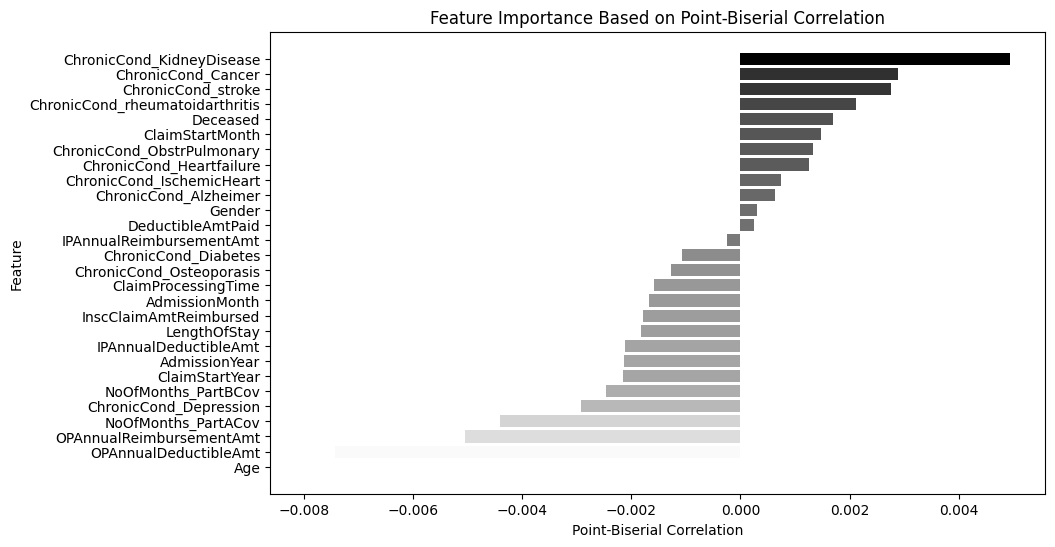

In [93]:
#Point Bi- Serial For Feature Selection
# Normalize the Point-Biserial Correlation values to the range [0, 1]
norm = plt.Normalize(vmin=point_biserial_df_sorted['Point-Biserial Correlation'].min(),
                     vmax=point_biserial_df_sorted['Point-Biserial Correlation'].max())

# Set colormap to 'Greys' for grayscale using matplotlib.colormaps
cmap = matplotlib.colormaps['Greys']

# Plotting the bar chart
plt.figure(figsize=(10, 6))
bars = plt.barh(point_biserial_df_sorted['Feature'], 
                point_biserial_df_sorted['Point-Biserial Correlation'],
                color=cmap(norm(point_biserial_df_sorted['Point-Biserial Correlation'])))

# Add labels and title
plt.xlabel('Point-Biserial Correlation')
plt.ylabel('Feature')
plt.title('Feature Importance Based on Point-Biserial Correlation')

# Show the plot
plt.show()


In [94]:
#Standard Scaler For Numerical Columns
Numerical_Columns = ['NoOfMonths_PartACov', 'NoOfMonths_PartBCov','IPAnnualReimbursementAmt',
                  'IPAnnualDeductibleAmt','OPAnnualReimbursementAmt','OPAnnualDeductibleAmt',
                  'InscClaimAmtReimbursed','DeductibleAmtPaid','Age','ClaimProcessingTime',
                  'ClaimStartYear','LengthOfStay','AdmissionYear']

scaler = StandardScaler()
merged_data[Numerical_Columns] = scaler.fit_transform(merged_data[Numerical_Columns])

In [95]:
#Frequency Count Encoding For Categorical Columns With High Cardinality
def frequency_encoding(data, col):
    freq_map = data[col].value_counts().to_dict()
    data[col + '_encoded'] = data[col].map(freq_map)
    return data



Frequency_Categorical_Columns = ['Provider', 'AttendingPhysician', 'OperatingPhysician', 'OtherPhysician',
                               'ClmAdmitDiagnosisCode', 'DiagnosisGroupCode', 'ClmDiagnosisCode_1', 'ClmDiagnosisCode_2',
                               'ClmDiagnosisCode_3', 'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5', 'ClmDiagnosisCode_6',
                               'ClmDiagnosisCode_7', 'ClmDiagnosisCode_8', 'ClmDiagnosisCode_9', 'ClmDiagnosisCode_10',
                               'ClmProcedureCode_1', 'ClmProcedureCode_2', 'ClmProcedureCode_3',
                               'ClmProcedureCode_4', 'ClmProcedureCode_5', 'ClmDiagnosisCode_1_outpatient', 
                               'ClmDiagnosisCode_2_outpatient', 'ClmDiagnosisCode_3_outpatient',
                               'ClmDiagnosisCode_4_outpatient', 'ClmDiagnosisCode_5_outpatient',
                               'ClmDiagnosisCode_6_outpatient', 'ClmDiagnosisCode_7_outpatient',
                               'ClmDiagnosisCode_8_outpatient', 'ClmDiagnosisCode_9_outpatient',
                               'ClmDiagnosisCode_10_outpatient', 'ClmProcedureCode_1_outpatient',
                               'ClmProcedureCode_2_outpatient']

for col in Frequency_Categorical_Columns:
    merged_data = frequency_encoding(merged_data, col)
    
print (merged_data.head())
print(merged_data.columns)

      BeneID        DOB DOD  Gender  Race RenalDiseaseIndicator  State  \
3  BENE11002 1936-09-01 NaT       2     1                     0     39   
4  BENE11003 1936-08-01 NaT       1     1                     0     52   
5  BENE11003 1936-08-01 NaT       1     1                     0     52   
6  BENE11004 1922-07-01 NaT       1     1                     0     39   
7  BENE11004 1922-07-01 NaT       1     1                     0     39   

   County  NoOfMonths_PartACov  NoOfMonths_PartBCov  ...  \
3     280             0.076849             0.076195  ...   
4     590             0.076849             0.076195  ...   
5     590             0.076849             0.076195  ...   
6     270             0.076849             0.076195  ...   
7     270             0.076849             0.076195  ...   

   ClmDiagnosisCode_3_outpatient_encoded  \
3                                  330.0   
4                                    NaN   
5                                    NaN   
6                 

In [96]:
#Encoding Categorical Columns Via One Hot Encoding
Hot_Categorical_Columns = ['Gender','Race','RenalDiseaseIndicator','State','County',
                         'ChronicCond_Alzheimer','ChronicCond_Heartfailure','ChronicCond_KidneyDisease',
                         'ChronicCond_Cancer','ChronicCond_ObstrPulmonary','ChronicCond_Depression',
                         'ChronicCond_Diabetes','ChronicCond_IschemicHeart','ChronicCond_Osteoporasis',
                         'ChronicCond_rheumatoidarthritis','ChronicCond_stroke','ClmProcedureCode_5',
                         'ClmProcedureCode_3_outpatient','ClmProcedureCode_4_outpatient']

batch_1 = ['Gender','Race','RenalDiseaseIndicator']
batch_2 = ['State','County','ChronicCond_Alzheimer','ChronicCond_Heartfailure']
batch_3 = ['ChronicCond_KidneyDisease','ChronicCond_Cancer','ChronicCond_ObstrPulmonary','ChronicCond_Depression']
batch_4 = ['ChronicCond_Diabetes','ChronicCond_IschemicHeart','ChronicCond_Osteoporasis','ChronicCond_rheumatoidarthritis',]
batch_5 = ['ChronicCond_stroke','ClmProcedureCode_5','ClmProcedureCode_3_outpatient','ClmProcedureCode_4_outpatient']

def encode_in_batches(merged_data, batches):
    for batch in batches:
        merged_data = pd.get_dummies(merged_data, columns=batch, drop_first=True)
        print(f"Finished Encoding Batch: {batch}")
    return merged_data

        
batches = [batch_1, batch_2, batch_3, batch_4, batch_5]


merged_data = encode_in_batches(merged_data, batches)

Finished Encoding Batch: ['Gender', 'Race', 'RenalDiseaseIndicator']
Finished Encoding Batch: ['State', 'County', 'ChronicCond_Alzheimer', 'ChronicCond_Heartfailure']
Finished Encoding Batch: ['ChronicCond_KidneyDisease', 'ChronicCond_Cancer', 'ChronicCond_ObstrPulmonary', 'ChronicCond_Depression']
Finished Encoding Batch: ['ChronicCond_Diabetes', 'ChronicCond_IschemicHeart', 'ChronicCond_Osteoporasis', 'ChronicCond_rheumatoidarthritis']
Finished Encoding Batch: ['ChronicCond_stroke', 'ClmProcedureCode_5', 'ClmProcedureCode_3_outpatient', 'ClmProcedureCode_4_outpatient']


In [97]:
#Feature Selection
#Chi - Square Test

def chi_square_test(data, Frequency_Categorical_Columns, target):
    chi_square_results = []
    for col in Frequency_Categorical_Columns:
        # Create a contingency table between feature and target
        contingency_table = pd.crosstab(data[col + '_encoded'], data[target])
        
        # Perform the Chi-Square test
        chi2, p, dof, expected = chi2_contingency(contingency_table)
        
        # Store the results
        chi_square_results.append({
            'Feature': col,
            'Chi-Square Statistic': chi2,
            'p-value': p
        })
    
    return pd.DataFrame(chi_square_results)


chi_square_results = chi_square_test(merged_data, Frequency_Categorical_Columns, 'PotentialFraud')


chi_square_results.sort_values('p-value', ascending = True)

,Feature,Chi-Square Statistic,p-value
0,Provider,443730.760453,0.000000e+00
1,AttendingPhysician,157668.998288,0.000000e+00
2,OperatingPhysician,20384.218279,0.000000e+00
3,OtherPhysician,62064.199636,0.000000e+00
5,DiagnosisGroupCode,1506.244800,3.421913e-125
12,ClmDiagnosisCode_7,1196.798056,1.177102e-110
8,ClmDiagnosisCode_3,1165.178381,1.515534e-104
13,ClmDiagnosisCode_8,1133.532297,6.314617e-104
7,ClmDiagnosisCode_2,1163.404639,7.205717e-102
16,ClmProcedureCode_1,995.526384,8.845900e-95


In [98]:
#Building Model Random Forest 
#Defining Feature and Target Selection

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score


RF_Features = ['Provider_encoded', 'AttendingPhysician_encoded', 'OperatingPhysician_encoded', 
               'OtherPhysician_encoded','DiagnosisGroupCode_encoded', 'ClmDiagnosisCode_7_encoded',
               'ClmDiagnosisCode_3_encoded', 'ClmProcedureCode_1_encoded','ClmDiagnosisCode_1_encoded',
               'ClmDiagnosisCode_8_encoded']

x = merged_data[RF_Features]
y = merged_data['PotentialFraud']

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.2, random_state=42)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(x_train, y_train)

rf_test_predictions = rf_model.predict(x_test)

rf_test_proba = rf_model.predict_proba(x_test)[:, 1]

rf_test_roc_auc = roc_auc_score(y_test, rf_test_predictions)

print("Random Forest Test ROC-AUC: ", rf_test_roc_auc)
print("Random Forest Classification Report: ")
print(classification_report(y_test, rf_test_predictions))

Random Forest Test ROC-AUC:  0.7942656860170451
Random Forest Classification Report: 
              precision    recall  f1-score   support

           1       1.00      0.59      0.74     41376
           2       0.81      1.00      0.89     71709

    accuracy                           0.85    113085
   macro avg       0.90      0.79      0.82    113085
weighted avg       0.88      0.85      0.84    113085



In [99]:
#Data Cleaning
#Replace Missing or Nan Values With O
merged_data['Provider_encoded'].fillna(0, inplace=True)
merged_data['AttendingPhysician_encoded'].fillna(0, inplace=True)
merged_data['OperatingPhysician_encoded'].fillna(0, inplace=True)
merged_data['OtherPhysician_encoded'].fillna(0, inplace=True)
merged_data['DiagnosisGroupCode_encoded'].fillna(0, inplace=True)
merged_data['ClmDiagnosisCode_7_encoded'].fillna(0, inplace=True)
merged_data['ClmDiagnosisCode_3_encoded'].fillna(0, inplace=True)
merged_data['ClmProcedureCode_1_encoded'].fillna(0, inplace=True)
merged_data['ClmDiagnosisCode_1_encoded'].fillna(0, inplace=True)
merged_data['ClmDiagnosisCode_8_encoded'].fillna(0, inplace=True)
merged_data['ChronicCond_KidneyDisease_2'].fillna(0, inplace=True)
merged_data['ChronicCond_Cancer_2'].fillna(0, inplace=True)
merged_data['ChronicCond_ObstrPulmonary_2'].fillna(0, inplace=True)

In [100]:
#Building Model Gradient Boosting Machine 
#Defining Feature and Target Selection 

GBM_Features = ['Provider_encoded', 'AttendingPhysician_encoded', 'OperatingPhysician_encoded', 
               'OtherPhysician_encoded','DiagnosisGroupCode_encoded', 'ClmDiagnosisCode_7_encoded',
               'ClmDiagnosisCode_3_encoded', 'ClmProcedureCode_1_encoded','ClmDiagnosisCode_1_encoded',
               'ClmDiagnosisCode_8_encoded']

x = merged_data[GBM_Features]
y = merged_data['PotentialFraud']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Initialize the Gradient Boosting model
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)

# Train the model
gb_model.fit(x_train, y_train)

# Predict on the test set
gb_test_predictions = gb_model.predict(x_test)

# Calculate ROC-AUC score
gb_test_roc_auc = roc_auc_score(y_test, gb_test_predictions)

# Output results
print("Gradient Boosting Test ROC-AUC: ", gb_test_roc_auc)
print("Gradient Boosting Classification Report: ")
print(classification_report(y_test, gb_test_predictions))


Gradient Boosting Test ROC-AUC:  0.8384830823560252
Gradient Boosting Classification Report: 
              precision    recall  f1-score   support

           1       1.00      0.68      0.81     41376
           2       0.84      1.00      0.91     71709

    accuracy                           0.88    113085
   macro avg       0.92      0.84      0.86    113085
weighted avg       0.90      0.88      0.88    113085



In [65]:
#Building Model KNN
#Defining Feature and Target Selection# Defining Feature and Target Selection
KNN_Features = ['Provider_encoded', 'AttendingPhysician_encoded', 'OperatingPhysician_encoded', 
               'OtherPhysician_encoded','DiagnosisGroupCode_encoded', 'ClmDiagnosisCode_7_encoded',
               'ClmDiagnosisCode_3_encoded', 'ClmProcedureCode_1_encoded','ClmDiagnosisCode_1_encoded',
               'ClmDiagnosisCode_8_encoded']

x = merged_data[KNN_Features]  # Selecting features
y = merged_data['PotentialFraud']  # Selecting the target variable

# Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Initialize the KNN model with 5 neighbors (default)
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn_model.fit(x_train, y_train)

# Predict on the test set
knn_test_predictions = knn_model.predict(x_test)

# Get predicted probabilities for ROC-AUC (requires probability=True, but KNN needs distance to be calculated)
knn_test_proba = knn_model.predict_proba(x_test)[:, 1]

# Calculate ROC-AUC score
knn_test_roc_auc = roc_auc_score(y_test, knn_test_proba)

# Output results
print("KNN Test ROC-AUC: ", knn_test_roc_auc)
print("KNN Classification Report: ")
print(classification_report(y_test, knn_test_predictions))


KNN Test ROC-AUC:  0.9635733810240424
KNN Classification Report: 
              precision    recall  f1-score   support

           1       0.93      0.87      0.90     41376
           2       0.93      0.96      0.94     71709

    accuracy                           0.93    113085
   macro avg       0.93      0.92      0.92    113085
weighted avg       0.93      0.93      0.93    113085

